## Step 3 — Landmark MLP Model

In [28]:
# Cell 1 — Imports & Setup
import os, urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

!pip install mediapipe
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"MediaPipe version: {mp.__version__}")


Using device: mps
MediaPipe version: 0.10.32


In [29]:
# Cell 3 — Paths, Config & Download Hand Landmarker model
TRAIN_DIR        = Path("data/asl_alphabet_train/asl_alphabet_train")
MODEL_PATH       = Path("asl_landmark_mlp.pth")
NPZ_CACHE        = Path("landmark_features.npz")
LANDMARKER_MODEL = Path("hand_landmarker.task")

EPOCHS       = 40
BATCH_SIZE   = 512
LR           = 1e-3
VAL_SPLIT    = 0.15
NUM_FEATURES = 21 * 3   # 21 landmarks x (x, y, z)

# Only A-Z (skip "del", "nothing", "space" from grassknoted dataset)
TARGET_CLASSES = [chr(c) for c in range(ord('A'), ord('Z') + 1)]

# Download the hand landmarker model if not present
if not LANDMARKER_MODEL.exists():
    print("Downloading hand_landmarker.task ...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, LANDMARKER_MODEL)
    print("Downloaded.")
else:
    print(f"Model already present: {LANDMARKER_MODEL}")


Model already present: hand_landmarker.task


In [31]:
# Cell 4 — Download grassknoted/asl-alphabet dataset
!pip install kaggle

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()  # Uses ~/.kaggle/kaggle.json

DOWNLOAD_DIR = "./data"
if not TRAIN_DIR.exists():
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    print("Downloading grassknoted/asl-alphabet (~1 GB) ...")
    api.dataset_download_files("grassknoted/asl-alphabet", path=DOWNLOAD_DIR, unzip=True)
    print(f"Done. Dataset at: {TRAIN_DIR}")
else:
    print(f"Dataset already present: {TRAIN_DIR}")

# Verify classes
classes = sorted([d.name for d in TRAIN_DIR.iterdir()
                  if d.is_dir() and d.name in TARGET_CLASSES])
NUM_CLASSES = len(classes)
le = LabelEncoder().fit(classes)
print(f"Classes ({NUM_CLASSES}): {classes}")


Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
Done. Dataset at: data/asl_alphabet_train/asl_alphabet_train
Classes (26): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [32]:
# Cell 5 — Extract landmarks from all training images (with CLAHE + caching)

def make_landmarker(model_path: Path, mode=mp_vision.RunningMode.IMAGE):
    """Create a HandLandmarker using the MediaPipe Tasks API."""
    base_opts = mp_tasks.BaseOptions(model_asset_path=str(model_path))
    opts = mp_vision.HandLandmarkerOptions(
        base_options=base_opts,
        running_mode=mode,
        num_hands=1,
        min_hand_detection_confidence=0.3,
        min_hand_presence_confidence=0.3,
        min_tracking_confidence=0.3,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)

def apply_clahe(img_bgr):
    """Improve contrast on dark images using CLAHE on the L channel."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def extract_landmarks_from_dataset(train_dir: Path, cache_path: Path,
                                   target_classes: list[str]):
    """Extract hand landmarks from dataset. Uses cache if available."""
    if cache_path.exists():
        print(f"Loading cached features from {cache_path} ...")
        data = np.load(cache_path, allow_pickle=True)
        return data["X"], data["y"]

    landmarker = make_landmarker(LANDMARKER_MODEL)
    X, y = [], []

    class_dirs = sorted([d for d in train_dir.iterdir()
                         if d.is_dir() and d.name in target_classes])
    total = sum(len(list(d.glob("*.jpg"))) for d in class_dirs)
    done, detected = 0, 0
    print(f"Extracting landmarks from {total} images ({len(class_dirs)} classes)...")

    for class_dir in class_dirs:
        label = class_dir.name
        for img_path in class_dir.glob("*.jpg"):
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                done += 1
                continue

            # CLAHE to handle dark images
            img_bgr = apply_clahe(img_bgr)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mp_img  = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result  = landmarker.detect(mp_img)

            if result.hand_landmarks:
                lm  = result.hand_landmarks[0]
                row = np.array([[p.x, p.y, p.z] for p in lm],
                               dtype=np.float32).flatten()
                X.append(row)
                y.append(label)
                detected += 1

            done += 1
            if done % 2000 == 0:
                rate = detected / done * 100
                print(f"  {done}/{total} processed, {detected} detected ({rate:.1f}%) ...")

    landmarker.close()
    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    np.savez_compressed(cache_path, X=X, y=y)
    print(f"\nDone! {detected}/{done} images had landmarks ({detected/done*100:.1f}%)")
    print(f"Saved {len(X)} samples -> {cache_path}")
    return X, y

X_raw, y_str = extract_landmarks_from_dataset(TRAIN_DIR, NPZ_CACHE, TARGET_CLASSES)

# Refit LabelEncoder on actually-extracted classes
classes = sorted(set(y_str))
NUM_CLASSES = len(classes)
le = LabelEncoder().fit(classes)
print(f"Classes after extraction ({NUM_CLASSES}): {classes}")

y = le.transform(y_str).astype(np.int64)
print(f"Feature matrix: {X_raw.shape}  Labels: {y.shape}")


Loading cached features from landmark_features.npz ...
Classes after extraction (23): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('S'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z')]
Feature matrix: (153, 63)  Labels: (153,)


I0000 00:00:1773275107.099402 10685567 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1773275107.110547 10685569 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773275107.114912 10685569 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


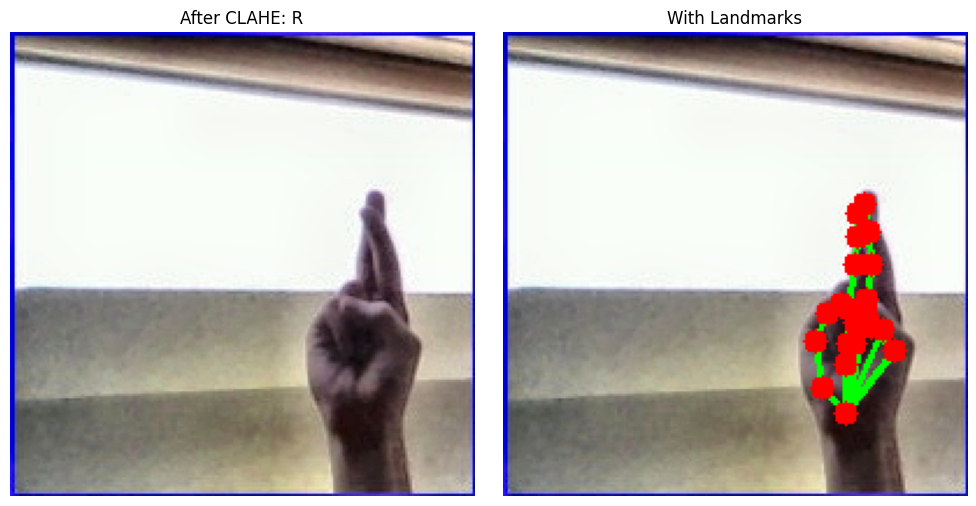

In [34]:
# Cell 6 — Visualise landmarks on a sample image
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

def draw_landmarks_cv(frame, landmarks):
    """Draw 21 keypoints + skeleton on a BGR frame (in-place)."""
    h, w = frame.shape[:2]
    pts = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for i, j in HAND_CONNECTIONS:
        cv2.line(frame, pts[i], pts[j], (0, 255, 0), 2)
    for pt in pts:
        cv2.circle(frame, pt, 5, (0, 0, 255), -1)

# Grab a sample
sample_class = next(d for d in TRAIN_DIR.iterdir()
                    if d.is_dir() and d.name in TARGET_CLASSES)
sample_path = next(sample_class.glob("*.jpg"))

img_bgr = apply_clahe(cv2.imread(str(sample_path)))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

landmarker_vis = make_landmarker(LANDMARKER_MODEL)
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
res = landmarker_vis.detect(mp_img)
landmarker_vis.close()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title(f"After CLAHE: {sample_class.name}")
axes[0].axis("off")

annotated = img_bgr.copy()
if res.hand_landmarks:
    draw_landmarks_cv(annotated, res.hand_landmarks[0])
    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title("With Landmarks")
else:
    axes[1].imshow(img_rgb)
    axes[1].set_title("No hand detected")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [35]:
# Cell 7 — Data Pipeline with Augmentation

class HandDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        landmarks = self.X[idx].reshape(21, 3).copy()

        if self.augment:
            # Random rotation (in-plane, +/-15 degrees)
            theta = np.radians(np.random.uniform(-15, 15))
            c, s = np.cos(theta), np.sin(theta)
            rot = np.array(((c, -s, 0), (s, c, 0), (0, 0, 1)))
            landmarks = landmarks @ rot

            # Random scale (+/-10%)
            landmarks *= np.random.uniform(0.9, 1.1)

            # Random jitter
            landmarks += np.random.normal(0, 0.002, landmarks.shape)

        # Normalize: center on wrist, scale to unit max distance
        landmarks -= landmarks[0]
        max_dist = np.linalg.norm(landmarks, axis=1).max()
        if max_dist > 0:
            landmarks /= max_dist

        return landmarks.flatten().astype(np.float32), self.y[idx]

# Filter singleton classes (can't stratify)
counts = Counter(y)
valid = np.array([counts[yi] >= 2 for yi in y])
X_filtered, y_filtered = X_raw[valid], y[valid]
n_removed = len(y) - len(y_filtered)
if n_removed > 0:
    print(f"Filtered out {n_removed} samples from singleton classes")

# Split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_filtered, y_filtered, test_size=VAL_SPLIT, random_state=42, stratify=y_filtered
)

train_dataset = HandDataset(X_train_raw, y_train, augment=True)
val_dataset   = HandDataset(X_val_raw,   y_val,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")


Filtered out 3 samples from singleton classes
Train: 127  Val: 23


In [36]:
# Cell 9 — MLP Classifier (63 -> 512 -> 256 -> 128 -> NUM_CLASSES)

class LandmarkMLP(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = LandmarkMLP(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)


Parameters: 201,495
LandmarkMLP(
  (net): Sequential(
    (0): Linear(in_features=63, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=23, bias=True)
  )
)


In [37]:
# Cell 10 — Training Loop

model = LandmarkMLP(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(feats)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * feats.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += feats.size(0)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train {tr_loss:.4f}/{tr_acc:.3f} | Val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({"model": model.state_dict(), "classes": classes}, MODEL_PATH)
        print(f"  -> Best model saved (val_acc={best_val_acc:.3f})")

print(f"\nBest val accuracy: {best_val_acc:.3f}")


Epoch 01/40 | Train 3.1973/0.008 | Val 3.1008/0.130
  -> Best model saved (val_acc=0.130)
Epoch 02/40 | Train 2.9749/0.236 | Val 3.0755/0.217
  -> Best model saved (val_acc=0.217)
Epoch 03/40 | Train 2.8122/0.441 | Val 3.0430/0.522
  -> Best model saved (val_acc=0.522)
Epoch 04/40 | Train 2.6681/0.449 | Val 3.0011/0.565
  -> Best model saved (val_acc=0.565)
Epoch 05/40 | Train 2.5512/0.433 | Val 2.9487/0.565
Epoch 06/40 | Train 2.4403/0.457 | Val 2.8856/0.609
  -> Best model saved (val_acc=0.609)
Epoch 07/40 | Train 2.3306/0.480 | Val 2.8116/0.609
Epoch 08/40 | Train 2.2687/0.472 | Val 2.7296/0.609
Epoch 09/40 | Train 2.1499/0.480 | Val 2.6432/0.609
Epoch 10/40 | Train 2.0989/0.465 | Val 2.5563/0.609
Epoch 11/40 | Train 2.0418/0.480 | Val 2.4705/0.609
Epoch 12/40 | Train 1.9609/0.480 | Val 2.3895/0.609
Epoch 13/40 | Train 1.9158/0.488 | Val 2.3139/0.609
Epoch 14/40 | Train 1.8722/0.551 | Val 2.2457/0.609
Epoch 15/40 | Train 1.8278/0.551 | Val 2.1832/0.609
Epoch 16/40 | Train 1.8234/0.5

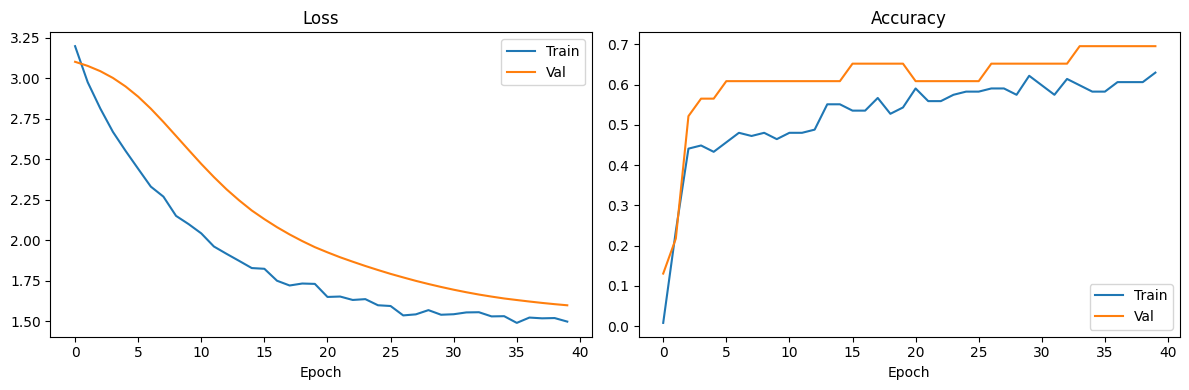

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


ValueError: Number of classes, 15, does not match size of target_names, 23. Try specifying the labels parameter

In [38]:
# Cell 12 — Training curves + sklearn evaluation

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set(title="Loss", xlabel="Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set(title="Accuracy", xlabel="Epoch"); ax2.legend()
plt.tight_layout(); plt.show()

# Load best checkpoint
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for feats, labels in val_loader:
        logits = model(feats.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes,
            cmap="Blues", ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout(); plt.show()


In [39]:
# Cell 14 — Local Webcam Inference (press 'q' to quit)

ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
classes = ckpt["classes"]

def normalise_row(landmarks) -> np.ndarray:
    row = np.array([[p.x, p.y, p.z] for p in landmarks], dtype=np.float32)
    row -= row[0]
    scale = np.linalg.norm(row, axis=1).max()
    if scale > 0:
        row /= scale
    return row.flatten()

def predict_landmarks(landmarks) -> tuple[str, float]:
    feat = normalise_row(landmarks)
    tensor = torch.from_numpy(feat).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    conf, idx = probs.max(0)
    return classes[idx.item()], conf.item()

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("ERROR: Cannot open webcam.")
else:
    landmarker_live = make_landmarker(LANDMARKER_MODEL, mode=mp_vision.RunningMode.IMAGE)
    print("Webcam opened. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        result = landmarker_live.detect(mp_img)

        if result.hand_landmarks:
            lm = result.hand_landmarks[0]
            draw_landmarks_cv(frame, lm)
            label, conf = predict_landmarks(lm)
            cv2.putText(frame, f"{label} ({conf:.0%})", (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        else:
            cv2.putText(frame, "No hand detected", (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        cv2.imshow("ASL Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    landmarker_live.close()
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam released.")


I0000 00:00:1773275176.228217 10686461 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1773275176.239141 10686462 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773275176.254062 10686462 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Webcam opened. Press 'q' to quit.
Webcam released.
